# Exploratory Data Analysis (EDA)

This analysis is performed on the cleaned Retail Store dataset to understand patterns, trends, and customer behavior.

The objective of this EDA is to extract meaningful insights that can help in better decision-making.

## Loading the Dataset

The cleaned dataset is loaded for analysis.

In [65]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.simplefilter(action='ignore', category='futurewarning')

df = pd.read_csv(r'C:\Users\AYUSH\Desktop\piyush python\Jupyter\Cleaned Data\cleaned_again_Retail_store.csv')

## Overview of The Dataset

In [66]:
df.head()

,Transaction ID,Customer ID,Category,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date
0,TXN_6867343,CUST_09,Patisserie,18.5,10,185.0,Digital Wallet,Online,2024-04-08
1,TXN_3731986,CUST_22,Milk Products,29.0,9,261.0,Digital Wallet,Online,2023-07-23
2,TXN_9303719,CUST_02,Butchers,21.5,2,43.0,Credit Card,Online,2022-10-05
3,TXN_9458126,CUST_06,Beverages,27.5,9,247.5,Credit Card,Online,2022-05-07
4,TXN_4575373,CUST_05,Food,12.5,7,87.5,Digital Wallet,Online,2022-10-02


In [67]:
df.tail()

,Transaction ID,Customer ID,Category,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date
12570,TXN_9347481,CUST_18,Patisserie,38.0,4,152.0,Credit Card,In-store,2023-09-03
12571,TXN_4009414,CUST_03,Beverages,6.5,9,58.5,Cash,Online,2022-08-12
12572,TXN_5306010,CUST_11,Butchers,14.0,10,140.0,Cash,Online,2024-08-24
12573,TXN_5167298,CUST_04,Furniture,14.0,6,84.0,Cash,Online,2023-12-30
12574,TXN_2407494,CUST_23,Food,17.0,3,51.0,Cash,Online,2022-08-06


In [68]:
print('No. of Rows:',df.shape[0])
print('No. of Columns:',df.shape[1])

No. of Rows: 12575
No. of Columns: 9


In [69]:
print('\nInformation about the data:\n')
df.info()


Information about the data:

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Price Per Unit    12575 non-null  float64
 4   Quantity          12575 non-null  int64  
 5   Total Spent       12575 non-null  float64
 6   Payment Method    12575 non-null  str    
 7   Location          12575 non-null  str    
 8   Transaction Date  12575 non-null  str    
dtypes: float64(2), int64(1), str(6)
memory usage: 1.6 MB


In [70]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,12575.000000,12575.000000,12575.000000
mean,23.348191,5.558648,127.603101
std,10.480413,2.790160,90.196853
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,57.000000
50%,23.000000,6.000000,108.500000
75%,32.000000,8.000000,180.000000
max,41.000000,10.000000,410.000000


## Fixing Data Types After Loading

In [71]:
# For Category Type:
cat = ['Location','Category','Payment Method']
df[cat] = df[cat].astype('category')

# For int Type:
df['Quantity'] = df['Quantity'].astype('int')

# For Date Type:
df['Transaction Date'] =  pd.to_datetime(df['Transaction Date'], errors='coerce')

In [72]:
df.dtypes

Transaction ID                 str
Customer ID                    str
Category                  category
Price Per Unit             float64
Quantity                     int64
Total Spent                float64
Payment Method            category
Location                  category
Transaction Date    datetime64[us]
dtype: object

After loading the dataset, data types such as datetime, category and others are re-assigned 
since CSV files do not preserve original data types.

## Sales by Category

This analysis shows how total sales are distributed across different product categories.

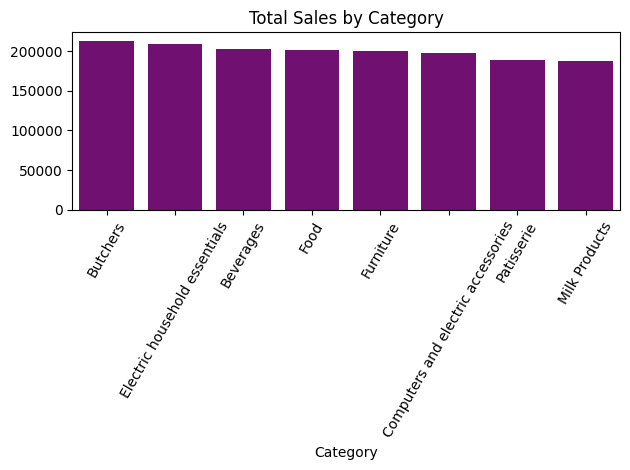

In [73]:
category_sales = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False)

sns.barplot(
    x = category_sales.index, 
    y=category_sales.values, 
    order=category_sales.index,
    color='purple'
)
plt.title('Total Sales by Category')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

### Insight

Sales are fairly balanced across all categories. 
Butchers has the highest sales, while Milk Products and Patisserie have slightly lower sales.

## Sales by Location

This analysis examines how sales vary across locations.

In [74]:
payment_option = df.groupby('Location')['Total Spent'].sum().reset_index()

fig = px.pie(
    payment_option, 
    names='Location',
    values ='Total Spent', 
    hole = 0.5, 
    title='Total Sales by Location'
)

fig.update_traces(textinfo="label+percent", pull=[0.05,0])

# fig.show()

### Insight

Sales from online transactions are slightly higher than in-store sales. 
However, the difference is minimal, indicating that both channels contribute almost equally to the overall revenue.

This suggests that customers are actively using both online and in-store purchasing options.

## Payment Method Distribution

This section analyzes the distribution of different payment methods used by customers.

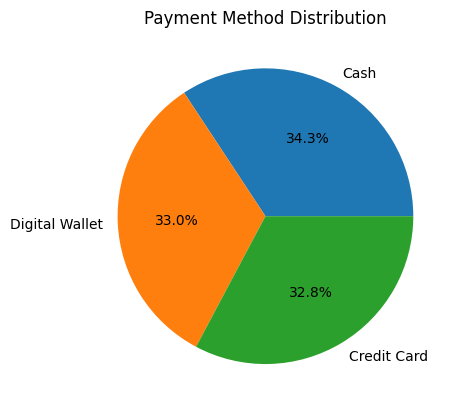

In [75]:
df['Payment Method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.ylabel('')
plt.show()

### Insight

Payment methods are evenly distributed across customers, with Cash (34.3%) slightly leading, followed closely by Digital Wallet (33.0%) and Credit Card (32.8%), indicating no strong preference for a single payment mode.

## Quantity Distribution

This analysis shows how many items customers typically purchase per transaction.

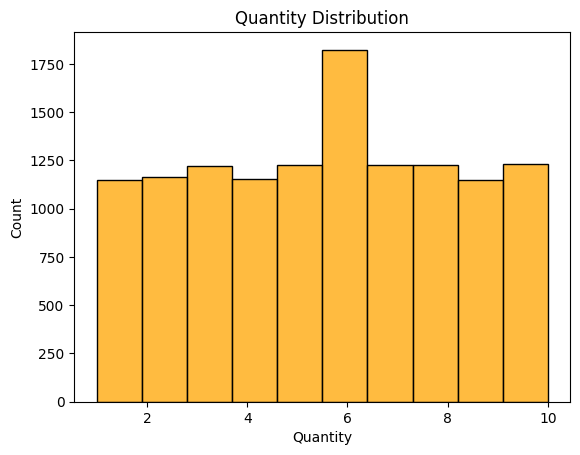

In [79]:
sns.histplot(df['Quantity'], bins=10, color='orange')
plt.title('Quantity Distribution')
plt.show()

### Insight

The quantity purchased is fairly evenly distributed across values from 1 to 10. 
However, most purchases are slightly concentrated around the middle range (around 5–7 units), 
indicating that customers commonly buy moderate quantities.

## Price Per Unit Distribution

This analysis explores how product prices are distributed.

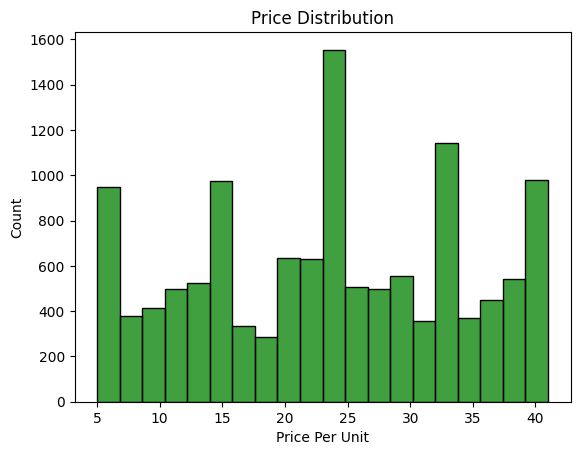

In [78]:
sns.histplot(df['Price Per Unit'], bins=20, color='green')
plt.title("Price Distribution")
plt.show()

### Insight

The price per unit is spread across a wide range, with most values concentrated around the mid-range (20–30). 
This suggests that most products are priced moderately, with fewer items at extremely low or high prices.

## Monthly Sales Trend

This analysis tracks how sales change over time on a monthly basis.

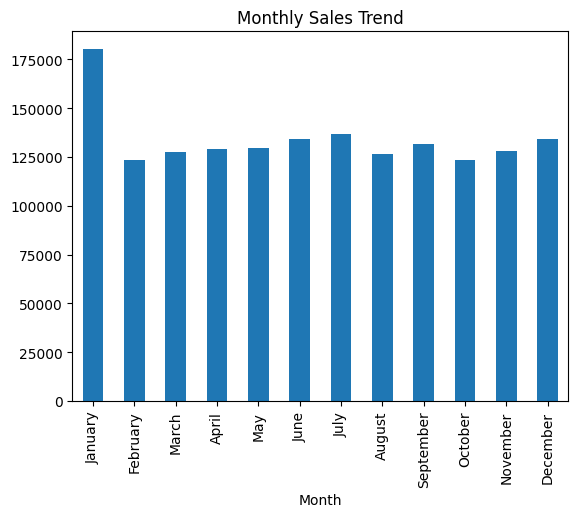

In [83]:
df['Month'] = pd.to_datetime(df['Transaction Date']).dt.month_name()

month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

monthly_sales = df.groupby('Month')['Total Spent'].sum()

monthly_sales.plot(kind='bar')
plt.title("Monthly Sales Trend")
plt.xticks(rotation=90)
plt.show()

### Insight

Sales remain relatively stable throughout the year with slight fluctuations. 
January shows the highest sales, while some months like February and October are slightly lower. 
Overall, there is no strong seasonal pattern, indicating consistent demand across months.

## Overall Insights

- Sales are evenly distributed across different product categories, indicating a balanced product demand.
- Online and in-store sales contribute almost equally, showing strong performance across both channels.
- All payment methods are used almost equally, showing balanced customer preferences.
- Prices are mostly concentrated in the mid-range, suggesting a moderate pricing strategy.
- Customers tend to purchase moderate quantities rather than very low or very high amounts.
- Monthly sales remain stable with no strong seasonal trends.

## Conclusion

The analysis shows that the business has a stable and well-balanced performance across different categories, locations, and time periods.

There is no heavy dependence on a single product category or sales channel, which indicates a diversified and low-risk revenue structure.

Customer purchasing behavior is consistent, with moderate quantities and mid-range pricing dominating the dataset.

Overall, the business demonstrates steady demand and operational stability.